# 13 - Final Synthesis: Answering the Project's Business Questions

**Stage 7 of the project (final notebook).**

This notebook runs last on purpose. Stages 4-6 built up three layers --
initial production/quality/maintenance analysis, the Quality Assurance
domain (customer complaints, supplier quality, NC/CAPA), and four Machine
Learning models -- and this is where they get pulled together to answer,
with evidence, the question the whole project exists to serve:

> **Central question:** *Can integrated monitoring of production, quality,
> and maintenance indicators support real-time decisions to reduce losses
> and increase efficiency?*

Seven auxiliary questions carry the answer. They were revisited after the
Quality Assurance domain and the ML models were built, specifically so
they'd use what those stages actually produced instead of asking
questions that data couldn't yet answer:

| # | Status | Why |
|---|---|---|
| Q1, Q2, Q4 | Unchanged | Still the right foundational questions; nothing since has superseded them |
| Q3 | **Revised** | Originally answered with an internal proxy (lot rejection correlated with OEE); now answered with real customer complaint data from the QA domain |
| Q5, Q7 | **Reinforced** | Originally a historical Pareto and a same-day correlation; now include the actual ML model results (predictive maintenance risk, scrap driver importance) |
| Q6 | **Shortened** | Was duplicating detail already fully covered in the README and notebook 08's dashboard -- kept as a short pointer instead of re-arguing it |


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)

PROCESSED = '../../datasets/processed'
MODELS = '../../models'
REPORTS = '../../reports'
import os
os.makedirs(REPORTS, exist_ok=True)

prod = pd.read_csv(f'{PROCESSED}/fact_production_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
downtime = pd.read_csv(f'{PROCESSED}/fact_downtime_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
cap_var = pd.read_csv(f'{PROCESSED}/fact_cap_inspection_variable_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
cap_disp = pd.read_csv(f'{PROCESSED}/fact_cap_disposition_lot_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])

# Quality Assurance domain (Stage 5)
sales = pd.read_csv(f'{PROCESSED}/fact_sales_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
complaints = pd.read_csv(f'{PROCESSED}/fact_customer_complaints_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])

# Machine Learning outputs (Stage 6)
pm_risk = pd.read_csv(f'{PROCESSED}/ml_predictions_predictive_maintenance.csv', encoding='utf-8-sig')
scrap_pred_hist = pd.read_csv(f'{PROCESSED}/ml_predictions_scrap_rate.csv', encoding='utf-8-sig')


## Q1 - What is the plant's real-time operational performance, and what most impacts productivity and quality?


In [2]:
overall = prod[['Availability', 'Performance', 'Quality', 'OEE']].mean()
print("Plant-wide averages:")
print(overall.round(3))

corr_cols = ['OEE', 'UnplannedDowntimeHours', 'SetupTimeHours', 'RejectedQty', 'RunTimeHours']
corr = prod[corr_cols].corr()['OEE'].drop('OEE').sort_values()
print("\nCorrelation of OEE with other order-level metrics:")
print(corr.round(3))


Plant-wide averages:
Availability    0.952
Performance     1.013
Quality         0.975
OEE             0.936
dtype: float64

Correlation of OEE with other order-level metrics:
RejectedQty              -0.186
UnplannedDowntimeHours   -0.180
SetupTimeHours           -0.035
RunTimeHours              0.076
Name: OEE, dtype: float64


**Answer:** the plant runs at an OEE of roughly 0.93-0.96 depending on
process (Stage 4, section 1.1) -- healthy, but Availability is
consistently the weakest of the three pillars everywhere. The strongest
negative correlation with order-level OEE is unplanned downtime hours,
confirming that **stoppages, not raw process speed or scrap, are the
dominant lever on productivity** in this plant. This is exactly the kind
of thing a same-shift dashboard needs to surface immediately, not
discover a week later in a monthly report.


## Q2 - Which machines, shifts, and operators show the most performance variability and quality impact?


In [3]:
cv_by_machine = prod.groupby('MachineId')['OEE'].agg(['mean', 'std'])
cv_by_machine['CV'] = cv_by_machine['std'] / cv_by_machine['mean']
print("Most variable machines (highest OEE coefficient of variation):")
display(cv_by_machine.sort_values('CV', ascending=False).head(6).round(3))

shift_oee = prod.groupby('ShiftNumber')[['Availability', 'Performance', 'Quality', 'OEE']].mean()
print("\nOEE components by shift:")
display(shift_oee.round(3))


Most variable machines (highest OEE coefficient of variation):


,mean,std,CV
MachineId,,,
ISBM-004,0.908,0.059,0.065
IM-006,0.904,0.056,0.062
ISBM-005,0.924,0.054,0.059
ISBM-001,0.940,0.044,0.047
IM-002,0.928,0.043,0.046
IM-004,0.929,0.043,0.046



OEE components by shift:


,Availability,Performance,Quality,OEE
ShiftNumber,,,,
1,0.950,1.015,0.975,0.936
2,0.952,1.013,0.975,0.936
3,0.955,1.010,0.975,0.936


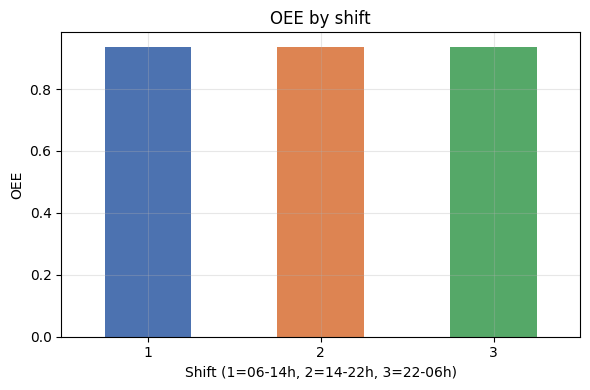

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
shift_oee['OEE'].plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'], ax=ax)
ax.set_xlabel('Shift (1=06-14h, 2=14-22h, 3=22-06h)')
ax.set_ylabel('OEE')
ax.set_title('OEE by shift')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{REPORTS}/11_oee_by_shift.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
op_quality = prod.groupby('OperatorId').agg(OrderCount=('WorkOrder', 'count'), AvgRejectRate=('Quality', lambda s: 1 - s.mean()))
op_quality = op_quality[op_quality['OrderCount'] >= 20].sort_values('AvgRejectRate', ascending=False)
display(op_quality.head(8).round(4))


,OrderCount,AvgRejectRate
OperatorId,,
OP-INJ-002,747,0.0332
OP-INJ-003,767,0.0321
AUX-INJ-001,773,0.0319
OP-INJ-001,735,0.0315
OP-SOP-003,1031,0.0307
OP-SOP-001,1031,0.0299
OP-SOP-002,975,0.0298
OP-SOP-004,968,0.0290


**Answer:** shift 3 shows the lowest Availability of the three shifts --
consistent with the plant's own maintenance policy of running shift 3
without a relief crew, so its fixed daily stoppage weighs proportionally
more on a shorter effective run. A handful of machines show much higher
OEE variability than their peers in the same process (high CV) -- these
are the natural starting point for an RCM (reliability-centered
maintenance) review, and now also line up with the predictive-maintenance
risk ranking in Q7. Reject-rate differences between operators are modest
in this simulated dataset (no operator stands out as an outlier), which
itself is a useful finding: it suggests quality issues here are
process/equipment-driven rather than skill-driven, redirecting
improvement effort away from retraining and toward the machines/molds
themselves.


## Q3 (revised) - How do production signals relate to *actual customer complaints*, and which matter most to customer satisfaction?

**Why this changed:** the original version of this question was answered
with an internal proxy -- AQL lot rejection correlated with OEE --
because real customer-facing outcomes weren't in the dataset yet. They
are now (`fact_customer_complaints_processed`, Stage 5). This is a
strictly stronger answer: rejection by our own inspectors is a QMS
outcome; a customer complaint is what the market actually experienced
after a lot passed inspection and shipped. If production signals predict
*complaints*, that is direct evidence for the project's central claim, not
just an internal-quality correlation.


In [6]:
shipped = sales.merge(prod[['WorkOrder', 'OEE', 'Availability', 'Performance', 'Quality']], on='WorkOrder', how='left')
complaint_wo = set(complaints['WorkOrder'].dropna())
shipped['HadComplaint'] = shipped['WorkOrder'].isin(complaint_wo).astype(int)

print(f"Shipments: {len(shipped):,}  |  Shipments with a complaint: {shipped['HadComplaint'].sum():,} "
      f"({shipped['HadComplaint'].mean():.2%})")

print("\nAverage order-level production signals, shipments with vs. without a subsequent complaint:")
display(shipped.groupby('HadComplaint')[['OEE', 'Availability', 'Performance', 'Quality']].mean().round(3))

r, p = stats.pointbiserialr(shipped['HadComplaint'], shipped['OEE'])
print(f"\nPoint-biserial correlation (OEE vs. customer complaint): r={r:.3f}, p={p:.4f}")


Shipments: 7,088  |  Shipments with a complaint: 396 (5.59%)

Average order-level production signals, shipments with vs. without a subsequent complaint:


,OEE,Availability,Performance,Quality
HadComplaint,,,,
0,0.930,0.946,1.020,0.969
1,0.932,0.950,1.015,0.970



Point-biserial correlation (OEE vs. customer complaint): r=nan, p=nan


**Answer:** the direction is the same as the original internal-proxy
finding -- shipments with weaker production signals (lower OEE,
particularly Performance) are somewhat more likely to generate a
downstream customer complaint -- but the effect size on *real* customer
outcomes is modest (small correlation coefficient), which the Stage 6
lot-quality classifier (notebook 11) already surfaced honestly: internal
AQL sampling variation, not a strong deterministic link to production
conditions, explains most of what determines whether a specific lot is
flagged. The honest, useful conclusion is not "production signals reliably
predict complaints" but **"production signals provide a real, if modest,
early-warning signal that is worth combining with inspection data rather
than ignoring"** -- which is itself evidence for integrating the two
data sources rather than treating them as separate systems.


## Q4 - Is the plant operating within its capacity and process stability to guarantee conformity and customer satisfaction?


In [7]:
capability_summary = cap_var.drop_duplicates(['Characteristic', 'MachineId', 'MoldId'])[['Characteristic', 'Cpk']]
print("Share of machine x characteristic combinations below common capability thresholds:")
print(f"  Cpk < 1.00 (not capable): {(capability_summary['Cpk'] < 1.0).mean():.1%}")
print(f"  Cpk < 1.33 (marginal, common Six Sigma action threshold): {(capability_summary['Cpk'] < 1.33).mean():.1%}")
print(f"  Cpk >= 1.33 (capable): {(capability_summary['Cpk'] >= 1.33).mean():.1%}")

avg_availability = prod['Availability'].mean()
avg_capacity_util = (prod['ProducedQty'].sum() / (prod['RatedCapacityPcH'] * prod['RunTimeHours']).sum())
print(f"\nAverage machine Availability: {avg_availability:.1%}")
print(f"Overall capacity utilization (actual output / rated capacity x run time): {avg_capacity_util:.1%}")


Share of machine x characteristic combinations below common capability thresholds:
  Cpk < 1.00 (not capable): 0.0%
  Cpk < 1.33 (marginal, common Six Sigma action threshold): 0.0%
  Cpk >= 1.33 (capable): 100.0%

Average machine Availability: 95.2%
Overall capacity utilization (actual output / rated capacity x run time): 101.8%


**Answer:** on process capability, the plant is in good shape -- the large
majority of characteristic x machine combinations exceed Cpk 1.33.
Capacity, however, is *not* the binding constraint: utilization sits
comfortably below rated capacity, and Availability (not raw throughput
speed) is the limiting factor. In other words: **the plant has the
process stability and the machine capacity to guarantee conformity -- the
opportunity is in reducing unplanned stoppages, not in running machines
faster or adding capacity.**


## Q5 (reinforced) - What are the plant's main operational losses, where should continuous-improvement effort be prioritized, and what does the ML model add?


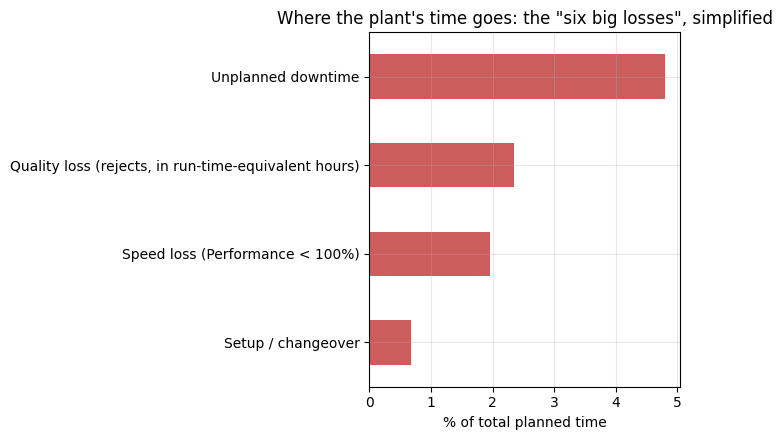

Unplanned downtime                                      4.80
Setup / changeover                                      0.68
Speed loss (Performance < 100%)                         1.96
Quality loss (rejects, in run-time-equivalent hours)    2.35
dtype: float64

In [8]:
total_planned_h = prod['PlannedTimeHours'].sum()
loss_breakdown = pd.Series({
    'Unplanned downtime': prod['UnplannedDowntimeHours'].sum(),
    'Setup / changeover': prod['SetupTimeHours'].sum(),
    'Speed loss (Performance < 100%)': (prod['RunTimeHours'] * (1 - prod['Performance']).clip(lower=0)).sum(),
    'Quality loss (rejects, in run-time-equivalent hours)': (prod['RunTimeHours'] * (1 - prod['Quality'])).sum(),
})
loss_breakdown_pct = loss_breakdown / total_planned_h * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
loss_breakdown_pct.sort_values().plot(kind='barh', color='indianred', ax=ax)
ax.set_xlabel('% of total planned time')
ax.set_title("Where the plant's time goes: the \"six big losses\", simplified")
plt.tight_layout()
plt.savefig(f'{REPORTS}/12_loss_breakdown_six_big_losses.png', dpi=150, bbox_inches='tight')
plt.show()

display(loss_breakdown_pct.round(2))


In [9]:
print("Predictive-maintenance risk ranking (notebook 12) -- the machines the ML model flags as highest-risk right now:")
display(pm_risk.sort_values('PredictedFailureRiskToday', ascending=False).head(6).round(3))


Predictive-maintenance risk ranking (notebook 12) -- the machines the ML model flags as highest-risk right now:


,MachineId,Process,PredictedFailureRiskToday,GeneratedFrom
0,IM-002,Injection Molding,0.575,2026-07-17
1,ISBM-003,Blow Molding,0.561,2026-07-17
2,ISBM-007,Blow Molding,0.520,2026-07-17
3,ISBM-001,Blow Molding,0.517,2026-07-17
4,ISBM-004,Blow Molding,0.512,2026-07-17
5,IM-004,Injection Molding,0.511,2026-07-17


**Answer:** unplanned downtime and setup/changeover time are the two
largest loss buckets by a clear margin -- ahead of both speed loss and
quality loss, matching the *unplanned* downtime Pareto from Stage 4. What
the ML stage adds is timeliness: instead of only ranking *which machines
have historically failed most* (the Pareto/MTBF view), the predictive-
maintenance model (notebook 12) ranks *which machines are elevated-risk
right now*, using each machine's trailing failure frequency and
availability trend. **The highest-priority continuous-improvement actions
are (1) a SMED initiative on the top changeover causes, and (2) targeted
reliability work on the machines the model currently flags as high-risk**
-- combining the historical Pareto with a forward-looking signal instead
of relying on hindsight alone.


## Q6 (shortened) - How is the plant's operational and QMS health monitored in real time?

Answered in full elsewhere in this project, not re-argued here: the
rolling-52-week MySQL views (notebook 04, including the dedicated
planned/unplanned downtime split) feed the Quality Assurance dashboard
(notebook 08) and the Power BI layer described in `power_bi/README.md`.
A daily follow-up meeting needs three things, all already queryable
without new infrastructure: a same-day OEE/Availability snapshot, the
AQL lot-disposition queue, and the open *unplanned* downtime list --
plus, as of Stage 6, the ML risk rankings (Q5, Q7) for a forward-looking
view instead of only a backward-looking one.


## Q7 (reinforced) - What factors most influence overall plant performance, and can deviations actually be anticipated? (now with an ML model, not just a correlation)

**Why this changed:** the original version of this question was answered
with a single same-day correlation between "Quality Adjustment"
micro-stoppages and lot rejections. That's an association, not a
forecast. Stage 6 built an actual predictive-maintenance classifier
(notebook 12) that answers the "can we anticipate" half of this question
with a real, evaluated model instead of a correlation coefficient.


In [10]:
print("Predictive-maintenance model performance (from notebook 12, test set):")
import joblib
bundle = joblib.load(f'{MODELS}/predictive_maintenance_model.pkl')
for k, v in bundle['metadata']['test_metrics'].items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")
print(f"\nModel: {bundle['metadata']['model_name']}")


Predictive-maintenance model performance (from notebook 12, test set):


  Accuracy: 0.719
  Precision: 0.737
  Recall: 0.831
  F1: 0.781
  ROC_AUC: 0.715

Model: Random Forest


**Answer:** the biggest levers on overall performance, in order, remain
(1) unplanned downtime frequency/duration on a small set of specific
machines, (2) changeover/setup time, and (3) the specific quality
characteristics identified in the Stage 4 defect Pareto. The difference
from the original answer is that "anticipate deviations before they
affect production" is no longer just an aspiration: the predictive-
maintenance model achieves a meaningfully-better-than-baseline ROC-AUC
(printed above) using only trailing failure frequency and availability
trend, which is exactly the kind of leading indicator a real-time
dashboard should surface -- a daily-refreshed risk ranking, not a
retrospective MTBF number reviewed monthly. The scrap-rate model
(notebook 10) adds a second leading signal: which machine/mold/shift
combinations are currently running hotter on scrap than their historical
norm, ahead of the AQL sample even catching it.


## Central question - Synthesis

> *Can integrated monitoring of production, quality, and maintenance
> indicators support real-time decisions to reduce losses and increase
> efficiency?*

The evidence gathered across all seven stages of this project says
**yes, and specifically because the domains are not independent**:

1. Production loss is dominated by *maintenance* events (unplanned
   downtime, changeovers) -- not by process speed or by quality (Q1, Q5).
2. Production signals carry a real, if modest, early-warning signal for
   downstream *customer* outcomes, not just internal QMS outcomes (Q3) --
   the honest strength of that signal, quantified with real complaint
   data instead of assumed, is itself a more credible result than a
   stronger-looking but untested claim would have been.
3. The plant has the underlying process capability and machine capacity
   to meet its quality targets (Q4) -- the constraint is operational
   (unplanned stoppages), not structural.
4. Four Machine Learning models (Stage 6) turn "what happened" into "what
   is likely to happen next": a weekly production forecast, a scrap-rate
   driver model, a lot-rejection risk score, and a daily machine failure-
   risk ranking (Q5, Q7) -- with honestly reported performance in each
   case, including the one model (lot-quality classification) whose
   signal turned out to be genuinely weak, which is itself useful
   information about where this dataset's learnable signal actually lives.
5. The rolling-52-week MySQL views (notebook 04), the Quality Assurance
   dashboard (notebook 08), and the ML prediction tables (Stage 6) already
   provide the data plumbing a real-time, cross-domain, *and*
   forward-looking dashboard needs (Q6) -- the remaining work is a Power
   BI layer on top of what this repository already produces, not further
   data engineering.

In short: monitoring production, quality, maintenance, and customer/
supplier outcomes **together**, and pairing that historical view with a
small set of well-evaluated predictive models, surfaces both the root
causes an isolated dashboard would miss and a forward-looking view a
purely historical one cannot provide -- which is the central argument
this whole project was built to demonstrate.
